In [2]:
# single-cell analysis package
library(Seurat)

# plotting and data science packages
library(repr)
library(stringr)
library(dplyr) 
library(tidyverse)
library(ggplot2)
library(cowplot)
library(patchwork)

# co-expression network analysis packages:
library(WGCNA)
library(hdWGCNA)

# enable parallel processing for network analysis (optional)
enableWGCNAThreads(nThreads = 8)

# using the cowplot theme for ggplot
theme_set(theme_cowplot())

# set random seed for reproducibility
set.seed(12345)

Allowing parallel execution with up to 8 working processes.


In [3]:
# load the unprocessed dataset
scObj_query <- readRDS(file.path('./HGSOC_scRNAseq_seurat_processed.rds'))
# set idents
Idents(scObj_query) <- scObj_query$cell_type

print(scObj_query)
print(table(scObj_query@meta.data$cell_type))
print(table(scObj_query@meta.data$patient_id))

An object of class Seurat 
32847 features across 51786 samples within 1 assay 
Active assay: RNA (32847 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, harmony, umap, tsne

    EOC  Immune Stromal 
   8806   34935    8045 

EOC1005  EOC136  EOC153  EOC227    EOC3  EOC349  EOC372  EOC443  EOC540  EOC733 
   4359    6103    3781    4193    5645    2954    5382    6585    3964    5819 
  EOC87 
   3001 


In [4]:
## Subset Tumor cell only
scObj_query <- subset(scObj_query, cell_type %in% c("EOC"))
scObj_query$cell_type <- as.factor(scObj_query$cell_type)
scObj_query$cell_type <- droplevels(scObj_query$cell_type)
print(scObj_query)
print(table(scObj_query@meta.data$cell_type))
print(table(scObj_query@meta.data$patient_id))
print(table(scObj_query@meta.data$treatment_phase))

An object of class Seurat 
32847 features across 8806 samples within 1 assay 
Active assay: RNA (32847 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, harmony, umap, tsne

 EOC 
8806 

EOC1005  EOC136  EOC153  EOC227    EOC3  EOC349  EOC372  EOC443  EOC540  EOC733 
    905    2632     446     231     426      96     412    1189     220    1922 
  EOC87 
    327 

      post-NACT treatment-naive 
           4239            4567 


In [5]:
# load the processed dataset
stObj_ref <- readRDS(file.path('./results/ST_tumor_hdWGCNA_object.rds'))
print(stObj_ref)
length(GetWGCNAGenes(stObj_ref))

An object of class Seurat 
33538 features across 11472 samples within 1 assay 
Active assay: Spatial (33538 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 4 dimensional reductions calculated: pca, harmony, umap, tsne
 8 spatial fields of view present: P1 P2 P3 P4 P5 P6 P7 P8


[1] 11729

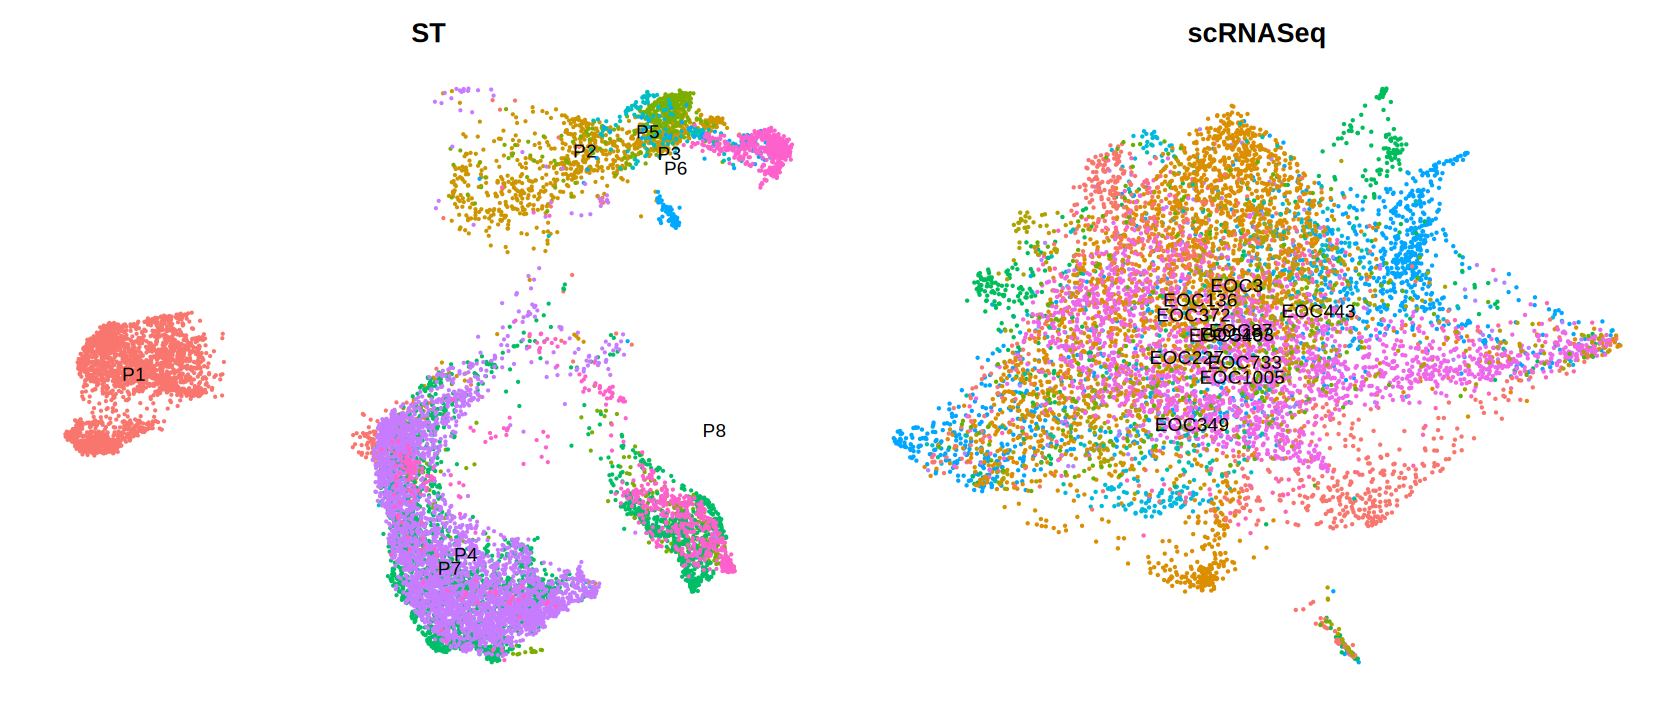

In [6]:
options(repr.plot.height = 6, repr.plot.width = 14)
p1 <- DimPlot(stObj_ref, group.by='patient', label=TRUE) +
   umap_theme() +
   ggtitle('ST') +
   NoLegend()

p2 <- DimPlot(scObj_query, group.by='patient_id', label=TRUE) +
   umap_theme() +
   ggtitle('scRNASeq') +
   NoLegend()

p1 + p2

In [7]:
# Project modules from query to reference dataset
seurat_query <- ProjectModules(
  seurat_obj = scObj_query,
  seurat_ref = stObj_ref,
  # vars.to.regress = c(), # optionally regress covariates when running ScaleData
  group.by.vars = "patient_id", # column in seurat_query to run harmony on
  wgcna_name_proj="projected", # name of the new hdWGCNA experiment in the query dataset
  wgcna_name = "HGSOC" # name of the hdWGCNA experiment in the ref dataset
)

Warning message in ProjectModules(seurat_obj = scObj_query, seurat_ref = stObj_ref, :
“The following modules will not be projected because too few genes are present in seurat_obj: ”


[1] "project modules"
[1] "Tumor-M1"


Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcaTumor-M1 to pcaTumorM1_”
pcaTumorM1_ 1 
Positive:  S100A4, EIF3D, SLC48A1, PRRX2, HOXD8, APLP1, GSDMD, TMPRSS4, AGPAT2, HP1BP3 
	   FAM69B, THEMIS2, KLK11, LINC01116, MEOX1, PINK1, SMPDL3A, PTGS1, KLK7, HSPA5 
	   MYRF, RPS19BP1, FAM50A, ISG20, HOXD9, NPAS3, RNF19A, SH3BP5, NEO1, MEGF6 
Negative:  B2M, HLA-B, HLA-A, HLA-DRA, HLA-E, HLA-DPA1, HLA-DRB1, HLA-DPB1, HLA-DQB1, IL32 
	   CD99, EMP3, HLA-DQA1, BST2, FTL, BASP1, MAP4K4, TAP1, C1R, HLA-F 
	   MAFB, TAP2, ACADVL, MGAT1, TLE1, EFNB2, COL6A2, COL6A1, C1S, IGFBP4 
pcaTumorM1_ 2 
Positive:  CD63, S100A4, HSPA5, GSN, KLK11, AGPAT2, PSAP, GSDMD, ISG20, CTSD 
	   PRRX2, TMPRSS4, PRSS23, PLEC, SH3BP5, SDF2L1, BIN1, CTSZ, CCNA1, PINK1 
	   APLP1, SLC44A2, CD276, HERPUD1, EIF3D, HEXA, MROH1, SERPINH1, RBM38, SLC48A1 
Negative:  FTL, IRF1, GBP1, GLDC, ICAM1, CALM3, DNAJC15, EFNA1, PI3, MAP7D1

[1] "grey"


Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcagrey to pcagrey_”
pcagrey_ 1 
Positive:  RARRES1, HEBP2, EIF3K, BBC3, STXBP6, RARRES3, EVA1C, RPL22, COX4I1, HIGD2A 
	   TSPO, FTH1, ELF3, FIS1, TNFAIP2, COX8A, ZC3H12A, LAMTOR4, COX7C, KLK8 
	   LINC01133, CEBPD, NFKBIA, NDUFB1, CRIP2, EPHB6, BLVRB, TM4SF1, FAM162A, NPC2 
Negative:  BZW1, EIF3A, KCNQ1OT1, EIF6, GLRX3, CDK6, EIF4G2, KRT10, SAR1A, EIF3J 
	   KATNBL1, RPL22L1, NOP10, POMP, GADD45GIP1, KPNB1, PMEPA1, SNRPD1, RRAS2, MAL2 
	   DDX21, MAFG, SNRPA1, SEC62, CYP1B1, EMC6, TNFRSF21, MISP, PSMD11, ASAP1 
pcagrey_ 2 
Positive:  SERPINB6, TATDN1, ATP6V0E1, HCFC1R1, EDF1, OCIAD2, TMEM141, MRPL33, S100A13, VAMP8 
	   NDUFC2, CYHR1, MAF1, RWDD1, EXOSC4, HSPA8, HACD3, EID1, PSMB7, RAB11A 
	   MPHOSPH8, PSMC5, SURF1, SEC11A, MRPL27, FIS1, COA4, BHLHE41, TMEM18, BLVRA 
Negative:  MAP2K3, RGS10, MYO10, BBC3, QSOX1, SSR2, DNAJB6, WTAP, TNFAI

...

Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcaTumor-M5 to pcaTumorM5_”
pcaTumorM5_ 1 
Positive:  FKBP1A, KLK5, GLUL, RAB4A, TMEM147, GPI, PRSS21, IRS2, NTN4, COX6B1 
	   TMEM183A, RRBP1, LSM14A, TMPRSS3, SERF2, RBCK1, CNN3, PRRC2C, UBA2, DHRS3 
	   ARF1, COX20, CP, H3F3A, GBP3, DMKN, NSFL1C, TMEM230, TOR1AIP2, ACTN4 
Negative:  VPS28, NDUFB9, UPK1B, BCAP31, WDR83OS, H2AFJ, ARPC3, IGFBP2, COX6A1, GRINA 
	   SUMO2, UCA1, EPCAM, MFSD3, LEMD1, ATP6AP1, ABHD11, PPP1R16A, PHB, WBP2 
	   CST3, SLC25A38, SLC39A4, TSPYL1, S100A1, METTL23, H3F3B, TSPAN3, PHLDA3, LYPD6B 
pcaTumorM5_ 2 
Positive:  SNRPB, CST3, NOP56, MTHFD2, EMC4, LSR, RAB1A, P4HB, KHSRP, LINC00665 
	   TMED2, CSRP1, CDC37, AKAP8L, HSP90B1, KRR1, MDM2, PPIB, NCL, PPP1CC 
	   FUS, DMKN, PRRC2C, TM9SF2, TRIP10, MYDGF, CSNK2A1, F11R, RNF10, METAP2 
Negative:  CHCHD10, KLK5, DEFB1, TPD52L1, TACSTD2, NDUFS5, GADD45A, RAB4A, NTPCR, U

[1] "Tumor-M6"


Centering and scaling data matrix

Warning message in irlba(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcaTumor-M6 to pcaTumorM6_”
pcaTumorM6_ 1 
Positive:  RPS18, RPS15A, RPS3, RPS14, RPS27A, RPL29, RPL32, RPL10A, RPL19, RPL12 
	   RPS3A, RPL23A, RPL13, RPL9, RPL37A, RPL18A, RPS13, RPS19, RPL27A, RACK1 
	   RPL3, RPL14, RPS7, RPS4X, RPL5, RPS23, RPL35A, RPS15, RPS2, RPL31 
Negative:  PTMA, GSTP1, TBX2, NPM1, IMPDH2, RPL17, RPL36A, EIF4B, BTF3, EEF2 
	   TOMM7, PFDN5, RPS29, RPL41, RPS10, TPT1, RPL8, FAU, RPL38, RPS12 
	   RPLP0, EEF1B2, RPLP1, RPL37, RPL35, RPS27, EEF1A1, RPL28, RPS21, RPL39 
pcaTumorM6_ 2 
Positive:  RPL13A, RPL28, RPL37, RPL18, RPS11, RPS16, RPS5, RPS6, RPS19, RPS27 
	   RPS23, RPL21, RPL18A, RPS9, RPL13, RPS2, RPLP2, BTF3, EEF1B2, RPL36 
	   RPS29, RPL35A, RPLP0, RPL

[1] "Tumor-M7"


Centering and scaling data matrix

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from pcaTumor-M7 to pcaTumorM7_”
pcaTumorM7_ 1 
Positive:  ANXA2, WNT7A, MFGE8, CST6, S100A10, LYPD1, RPL36AL, CLIC1, KLK6, DCBLD2 
	   SPOCK2, ACTG1, PDLIM1, PLPP2, LGALS3, APLP2, ZBED2, ID4, EIF1, MUC16 
	   CLDN10, VMP1, DPP4, NPDC1, ITGB4, SCX, KRT18, S100A6, CLIC5, RPS27L 
Negative:  SOD2, PDZK1IP1, C3, IFITM3, WFDC2, GAS6, MUC1, BCAM, PPP1R1B, LCN2 
	   NNMT, FOLR1, SAA1, DUSP23, COMMD6, IFITM2, LAMA3, SMARCD3, KLK10, FAM20A 
	   PTGER2, SAA2, RAB25, KRTCAP3, THSD4, MGLL, NR2F1, KCNN4, S100A11, NPR1 
pcaTumorM7_ 2 
Positive:  KRT7, LCN2, S100A11, PTGES, KRT19, SLPI, LYPD2, MUC1, TGM2, CYBA 
	   MGLL, C19orf33, SPOCK2, PTTG1IP, LAMB3, LAMC2, CLU, KRT18, IFITM1, KRT8 
	   PPL, EPS8L2, ANXA11, LGALS3, EPS8L1, ADIRF, RARRES2, C3, TGM1, CLDN1 
Negative:  ID4, ASRGL1, LYPD1, SNRPD2, NR2F1, NDUFA4L2, EIF1, CDH2, SCX, RPL36AL 
	   DPP4, CRLF1, SMA

In [8]:
# construct metacells for query:
seurat_query <- MetacellsByGroups(
  seurat_obj = seurat_query,
  group.by = c( "cell_type"),
  k = 25,
  max_shared = 12,
  reduction = 'harmony',
  ident.group = 'cell_type'
)
seurat_query <- NormalizeMetacells(seurat_query)

Normalizing layer: counts



In [9]:
# set expression matrix for reference dataset
seurat_ref <- SetDatExpr(
  stObj_ref,
  group_name = "Tumour_cells",
  group.by = "cell_type"
)

# set expression matrix for query dataset:
seurat_query <- SetDatExpr(
  seurat_query,
  group_name = "EOC",
  group.by = "cell_type"
)

Warning message in SetDatExpr(stObj_ref, group_name = "Tumour_cells", group.by = "cell_type"):
“assay not specified, trying to use assay Spatial”
Warning message in SetDatExpr(seurat_query, group_name = "EOC", group.by = "cell_type"):
“assay not specified, trying to use assay RNA”


In [10]:
# run module preservation function
seurat_query <- ModulePreservation(
  seurat_query,
  seurat_ref = seurat_ref,
  name="HGSOC-Tumor",
  verbose=3,
  n_permutations=250 # n_permutations=20 used for the tutorial
)

[1] "ref:"
[1]  2782 11299
[1] "query:"
[1]  1000 11299
[1] 1
  ..checking data for excessive amounts of missing data..
     Flagging genes and samples with too many missing values...
      ..step 1
     Flagging genes and samples with too many missing values...
      ..step 1
  ..unassigned 'module' name: grey 
  ..all network sample 'module' name: gold
  ..calculating observed preservation values
  ..calculating permutation Z scores
 ..Working with set 1 as reference set
 ....working with set 2 as test set
  ......working on permutation 1
  ......working on permutation 2
  ......working on permutation 3
  ......working on permutation 4
  ......working on permutation 5
  ......working on permutation 6
  ......working on permutation 7
  ......working on permutation 8
  ......working on permutation 9
  ......working on permutation 10
  ......working on permutation 11
  ......working on permutation 12
  ......working on permutation 13
  ......working on permutation 14
  ......working on 

In [11]:
# get the module preservation table
mod_pres <- GetModulePreservation(seurat_query, "HGSOC-Tumor")$Z
obs_df <- GetModulePreservation(seurat_query, "HGSOC-Tumor")$obs

[1] "Zsummary.qual"
[1] "Zsummary.pres"


Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”


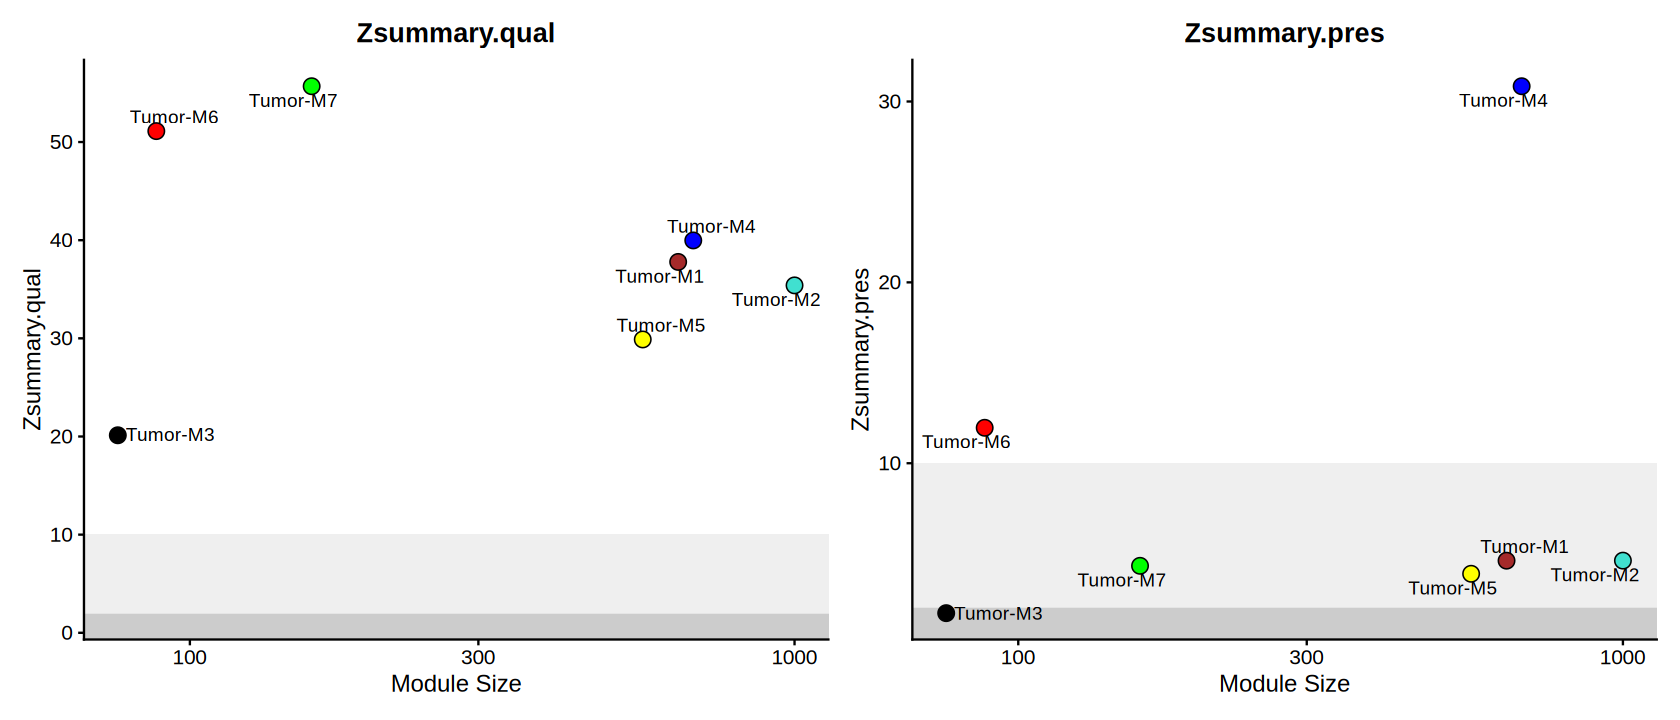

In [12]:
plot_list <- PlotModulePreservation(
  seurat_query,
  name="HGSOC-Tumor",
  statistics = "summary"
)

wrap_plots(plot_list, ncol=2)

In [13]:
# options(repr.plot.height = 6, repr.plot.width = 14)

# png(filename = "./results/module_preservation.png", width = 3000, height = 1500, res = 300)
# plot_list <- PlotModulePreservation(
#   seurat_query,
#   name="HGSOC-Tumor",
#   statistics = c("Zsummary.pres")
# )

# wrap_plots(plot_list, ncol=2)
# dev.off()

In [16]:
# saveRDS(seurat_query, file='./results/projected_scRNAseq_tumor_hdWGCNA_object.rds')